# Learning curves

- [Imbalanced Data: Myths, Mistakes and Modern Solutions](https://www.trainindata.com/p/imbalanced-data-myths-mistakes-solutions-book)

In this notebook, we plot learning curves to understand if we have enough data to train a reliable machine learning model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LearningCurveDisplay

from imblearn.datasets import fetch_datasets

In [2]:
# Load dataset from imbalanced-learn
def load_dataset(dataset):
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    return data.data, data.target

## Protein homo

This dataset contains 145751 samples, 74 features and an IR (imbalance ratio) of 111.

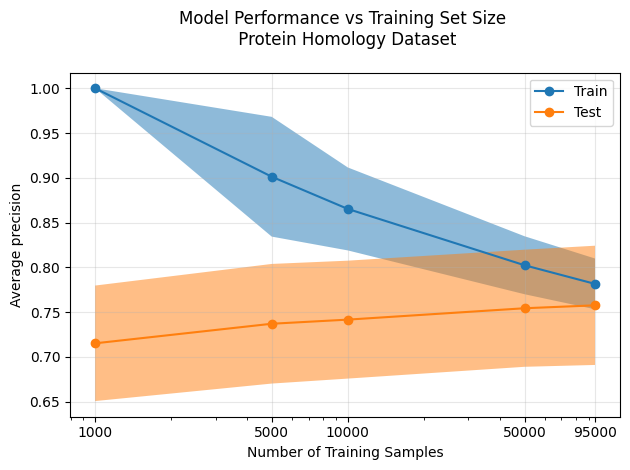

In [3]:
X, y = load_dataset("protein_homo")

model = RandomForestClassifier(max_depth=3, random_state=0)

# Absolute number of samples to evaluate.
train_sizes = [1000, 5000, 10000, 50000, 95000]

LearningCurveDisplay.from_estimator(
    model,
    X, y, 
    train_sizes=train_sizes, 
    cv=3,
    scoring='average_precision',
    shuffle=True,          # <--- shuffles the training folds before slicing
    random_state=0,        # <--- Guarantees reproducibility of the shuffles
    line_kw = {"marker": "o"},
)

plt.title('Model Performance vs Training Set Size \n Protein Homology Dataset', pad=20)
plt.xlabel('Number of Training Samples')
plt.ylabel('Average precision')
plt.xticks(train_sizes, train_sizes)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch1/ch1-fig3.png", dpi=300, bbox_inches="tight")
plt.show()

## Pen digits

This dataset contains 10992 samples, 16 features and an IR of 9.4

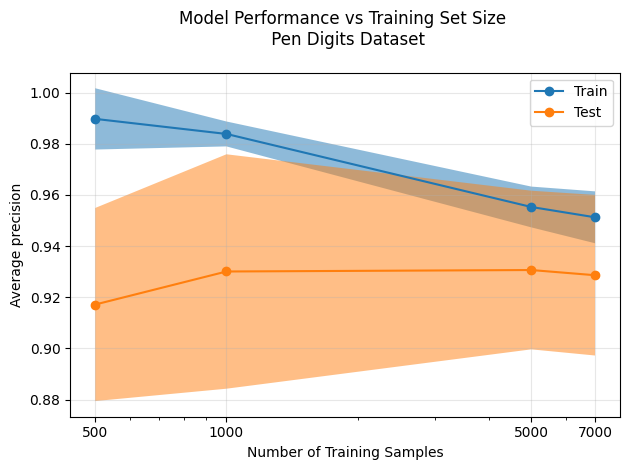

In [4]:
X, y = load_dataset("pen_digits")

model = RandomForestClassifier(max_depth=3, random_state=0)

train_sizes = [500, 1000, 5000, 7000]

LearningCurveDisplay.from_estimator(
    model,
    X, y, 
    train_sizes=train_sizes, 
    cv=3,
    scoring='average_precision',
    shuffle=True,          # <--- shuffles the training folds before slicing
    random_state=0,        # <--- Guarantees reproducibility of the shuffles
    line_kw = {"marker": "o"},
)

plt.title('Model Performance vs Training Set Size \n Pen Digits Dataset', pad=20)
plt.xlabel('Number of Training Samples')
plt.ylabel('Average precision')
plt.xticks(train_sizes, train_sizes)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch1/ch1-fig4.png", dpi=300, bbox_inches="tight")
plt.show()

With LearningCurveDisplay sometimes you get an error, when for example, there are not enough samples of the minority class to evaluate the metric. To avoid this, remember to set the `shuffle` parameter to `True` so the train set is shuffled before the cross-validation. This ensures there are instances of all classes across all folds. Also set the `random_state` parameter to an integer to guarantee reproducibility of the shuffles.

## Website

This dataset contains almost 34800 samples, 300 features and an IR of 34.

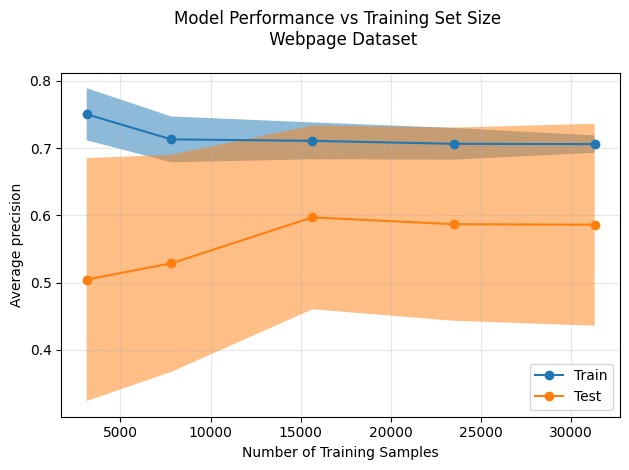

In [5]:
X, y = load_dataset("webpage")

model = RandomForestClassifier(max_depth=3, random_state=0)

# Percentage of training samples to evaluate
train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

LearningCurveDisplay.from_estimator(
    model,
    X, y,
    train_sizes=train_sizes,
    cv=10,
    scoring='average_precision',
    shuffle=True,          # <--- shuffles the training folds before slicing
    random_state=0,        # <--- Guarantees reproducibility of the shuffles
    line_kw = {"marker": "o"},
)

plt.title('Model Performance vs Training Set Size \n Webpage Dataset', pad=20)
plt.xlabel('Number of Training Samples')
plt.ylabel('Average precision')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch1/ch1-fig5.png", dpi=300, bbox_inches="tight")
plt.show()